# Value Function in Latent

**Companion to** [`research/03-value-function-in-latent.md`](../research/03-value-function-in-latent.md).

A value head $\hat v_\xi(z)$ estimates the expected return from a latent state. It is what lets a planner roll
out only a few steps and still "see" reward far beyond the horizon — by bootstrapping the tail with
$\hat v_\xi(\hat z_H)$. This notebook builds that intuition and then exposes the instability that makes value
learning hard.

**What we will see:**

1. **Bellman / TD(0)** — a value function is the fixed point of the Bellman operator; sampled TD(0) updates
   converge to the analytic solution on a small latent MDP.
2. **$\lambda$-return bias–variance** — $\lambda$ interpolates Monte-Carlo (unbiased, high variance) and TD
   (low variance, critic-biased); the estimator MSE is U-shaped in $\lambda$.
3. **Value bootstrap beats long rollouts** — with a value head, a *short* horizon already estimates return
   accurately; without it you need long rollouts that accumulate model error.
4. **The deadly triad** — bootstrapping + function approximation + off-policy data can make value estimates
   diverge, even when the true value is finite. Monte-Carlo (no bootstrap) stays bounded.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
    'axes.grid': True, 'grid.alpha': 0.35,
})
print('Setup complete.')

Setup complete.


## Experiment 1: Bellman fixed point and TD(0) convergence

**Question.** The value function is defined by a recursion, not a formula — does learning it from sampled
transitions actually land on the right answer?

On a 6-state latent chain (random-walk policy, reward only on reaching the right end, $\gamma=0.9$) the true
values solve the linear Bellman system $v = r + \gamma P v$, i.e. $v=(I-\gamma P)^{-1}r$. We then run
sampled **TD(0)** updates $v(z_t)\leftarrow v(z_t)+\alpha[r_t+\gamma v(z_{t+1})-v(z_t)]$ and watch the RMS
error to that exact solution.

In [2]:
nS = 6
P = np.zeros((nS, nS))
for s in range(nS):                      # random walk; ends are absorbing
    if s in (0, nS - 1):
        P[s, s] = 1.0
    else:
        P[s, s - 1] = 0.5; P[s, s + 1] = 0.5
r = np.zeros(nS); r[nS - 1] = 0.0
# reward on the transition INTO the right end
R = np.zeros((nS, nS)); R[nS - 2, nS - 1] = 1.0
gamma = 0.9
r_exp = (P * R).sum(1)                    # expected immediate reward per state
V_true = np.linalg.solve(np.eye(nS) - gamma * P, r_exp)
V_true[0] = 0.0; V_true[-1] = 0.0        # absorbing states have 0 value

rng = np.random.default_rng(0)
V = np.zeros(nS); alpha = 0.1
errs = []
for it in range(6000):
    s = rng.integers(1, nS - 1)
    sp = rng.choice(nS, p=P[s])
    rew = R[s, sp]
    target = rew + gamma * (0.0 if sp in (0, nS - 1) else V[sp])
    V[s] += alpha * (target - V[s])
    if it % 50 == 0:
        errs.append(np.sqrt(np.mean((V[1:-1] - V_true[1:-1]) ** 2)))
print('true values:', np.round(V_true, 3))
print('TD(0) values:', np.round(V, 3))

true values: [0.    0.105 0.234 0.414 0.686 0.   ]
TD(0) values: [0.    0.115 0.213 0.378 0.67  0.   ]


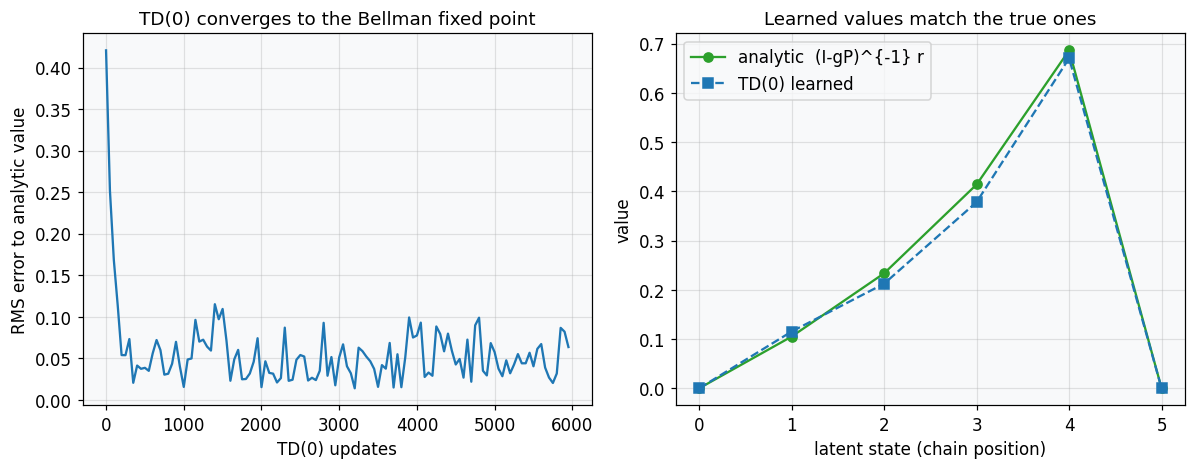

In [3]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.4))
axL.plot(np.arange(len(errs)) * 50, errs, color='#1f77b4')
axL.set_xlabel('TD(0) updates'); axL.set_ylabel('RMS error to analytic value')
axL.set_title('TD(0) converges to the Bellman fixed point')

st = np.arange(nS)
axR.plot(st, V_true, '-o', color='#2ca02c', label='analytic  (I-gP)^{-1} r')
axR.plot(st, V, '--s', color='#1f77b4', label='TD(0) learned')
axR.set_xlabel('latent state (chain position)'); axR.set_ylabel('value')
axR.set_title('Learned values match the true ones'); axR.legend()
plt.tight_layout(); plt.show()

### What you see

**Left:** the RMS error between the TD(0) estimate and the exact linear-algebra solution falls toward zero —
sampled one-step updates, each only touching two states, collectively solve the global Bellman system.

**Right:** the converged values rise monotonically toward the rewarding right end; states closer to reward are
worth more, discounted by $\gamma$ per step. The learned curve (blue) sits on top of the analytic one (green).

**Takeaway.** A value function is *defined* by Bellman self-consistency $v(z)=\mathbb{E}[r+\gamma v(z')]$, and
TD bootstrapping is how a critic is trained to satisfy it from experience — the exact mechanism Dreamer's
critic uses on imagined latent trajectories.

## Experiment 2: $\lambda$-return — trading bias for variance

**Question.** The bootstrap value is biased (the critic is imperfect); the Monte-Carlo return is unbiased but
noisy. How do we combine them?

The $\lambda$-return mixes all $n$-step returns. We take the chain above with its *true* values, hand the
estimator a deliberately **biased critic** $\hat v = V_{\text{true}} + b$, and sample many trajectories from
the start state. For each $\lambda$ we form the $\lambda$-return estimate of $V(s_0)$ and measure its squared
bias, variance, and total MSE.

In [4]:
bias_const = 0.15
V_hat = V_true + bias_const               # biased critic
start = 1

def sample_traj(rng, max_len=60):
    s, traj = start, []
    for _ in range(max_len):
        sp = rng.choice(nS, p=P[s]); traj.append((s, R[s, sp], sp)); s = sp
        if s in (0, nS - 1):
            break
    return traj

def lambda_return(traj, lam):
    # backward recursion: G = r + gamma*c*[(1-lam) v(s') + lam G']
    G = 0.0
    for s, rew, sp in reversed(traj):
        cont = 0.0 if sp in (0, nS - 1) else 1.0
        boot = V_hat[sp] if cont else 0.0
        G = rew + gamma * cont * ((1 - lam) * boot + lam * G)
    return G

rng = np.random.default_rng(7)
trajs = [sample_traj(rng) for _ in range(4000)]
lams = np.linspace(0, 1, 21)
bias2, var, mse = [], [], []
for lam in lams:
    ests = np.array([lambda_return(t, lam) for t in trajs])
    b = ests.mean() - V_true[start]
    bias2.append(b ** 2); var.append(ests.var()); mse.append(b ** 2 + ests.var())
bias2, var, mse = map(np.array, (bias2, var, mse))
print('lambda* (min MSE) =', round(lams[np.argmin(mse)], 2))

lambda* (min MSE) = 0.5


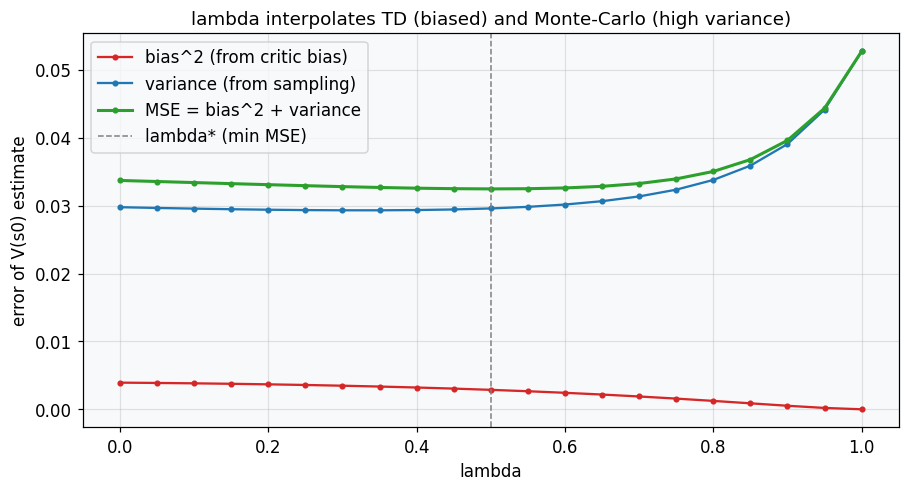

In [5]:
fig, ax = plt.subplots(figsize=(8.4, 4.6))
ax.plot(lams, bias2, '-o', ms=3, color='#d62728', label='bias^2 (from critic bias)')
ax.plot(lams, var, '-o', ms=3, color='#1f77b4', label='variance (from sampling)')
ax.plot(lams, mse, '-o', ms=3, color='#2ca02c', lw=2, label='MSE = bias^2 + variance')
ax.axvline(lams[np.argmin(mse)], color='gray', ls='--', lw=1, label='lambda* (min MSE)')
ax.set_xlabel('lambda'); ax.set_ylabel('error of V(s0) estimate')
ax.set_title('lambda interpolates TD (biased) and Monte-Carlo (high variance)')
ax.legend()
plt.tight_layout(); plt.show()

### What you see

At $\lambda=0$ (pure TD) the estimate leans entirely on the biased critic: variance is low but squared bias is
high. At $\lambda=1$ (Monte-Carlo) the bias vanishes but variance is largest. The total MSE (green) is
U-shaped, minimized at an intermediate $\lambda^*$ marked by the dashed line.

**Why.** Each extra step of real reward replaces one step of critic bootstrap: it removes critic bias but adds
sampling noise. $\lambda$ is the knob that balances the two, exactly the bias–variance trade-off.

**Takeaway.** Dreamer's choice of a $\lambda$-return is not arbitrary — it tunes how much the critic is
trusted versus the imagined rollout. The right $\lambda$ depends on how good the critic is and how noisy the
dynamics are; neither extreme is optimal.

## Experiment 3: why a value head lets you roll out *short*

**Question.** Tier-6 told us long rollouts accumulate model error. Does a value bootstrap let us avoid them?

We estimate return from the start state two ways as a function of planning horizon $H$: (a) **no bootstrap** —
sum $H$ steps of *model* reward and stop; (b) **with bootstrap** — sum $H$ steps and add $\gamma^H\hat v(z_H)$.
The model reward carries a small per-step error that compounds; the value head is imperfect but fixed. We plot
each estimate's error against the true return.

In [6]:
# true discounted return from start (closed form on the chain)
G_true = V_true[start]
v_err = 0.10                                  # fixed value-head error
model_rew_bias = 0.01                         # per-step model reward bias that compounds

def estimate(H, bootstrap, rng):
    s, G, disc = start, 0.0, 1.0
    for k in range(H):
        sp = rng.choice(nS, p=P[s]); rew = R[s, sp] + model_rew_bias * (k + 1)  # growing model bias
        G += disc * rew; disc *= gamma; s = sp
        if s in (0, nS - 1):
            return G, True
    if bootstrap:
        G += disc * (V_true[s] + v_err)        # imperfect value bootstrap
    return G, False

Hs = np.arange(1, 26)
rng = np.random.default_rng(11)
err_no, err_yes = [], []
for H in Hs:
    e_no = np.mean([abs(estimate(H, False, rng)[0] - G_true) for _ in range(800)])
    e_yes = np.mean([abs(estimate(H, True, rng)[0] - G_true) for _ in range(800)])
    err_no.append(e_no); err_yes.append(e_yes)
print('H=3   no-bootstrap err=%.3f  with-bootstrap err=%.3f' % (err_no[2], err_yes[2]))
print('H=25  no-bootstrap err=%.3f  with-bootstrap err=%.3f' % (err_no[-1], err_yes[-1]))

H=3   no-bootstrap err=0.074  with-bootstrap err=0.158
H=25  no-bootstrap err=0.211  with-bootstrap err=0.194


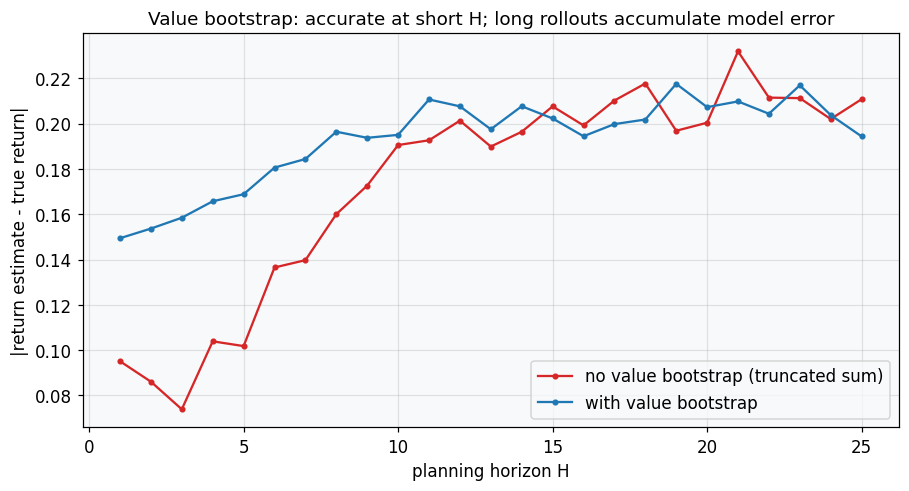

In [7]:
fig, ax = plt.subplots(figsize=(8.4, 4.6))
ax.plot(Hs, err_no, '-o', ms=3, color='#d62728', label='no value bootstrap (truncated sum)')
ax.plot(Hs, err_yes, '-o', ms=3, color='#1f77b4', label='with value bootstrap')
ax.set_xlabel('planning horizon H'); ax.set_ylabel('|return estimate - true return|')
ax.set_title('Value bootstrap: accurate at short H; long rollouts accumulate model error')
ax.legend()
plt.tight_layout(); plt.show()

### What you see

Without a value head (red) a short horizon badly under-counts return (it ignores everything past $H$), so you
must extend $H$ — but then the compounding model-reward bias takes over and the error climbs again. With a
value bootstrap (blue) even a short horizon is accurate: the value head supplies the discounted tail, and
because the rollout is short, little model error accumulates.

**Why.** $\gamma^H\hat v(z_H)$ replaces an infinite tail of model rollout with a single learned estimate. You
swap *dynamics* error (which compounds) for *critic* error (which does not compound with horizon).

**Takeaway.** The value function is what makes short-horizon latent planning both cheap and far-sighted —
the core reason Tier-7 planners (MPC, CEM, Dreamer) use a terminal value bootstrap instead of rolling to the
episode end.

## Experiment 4: the deadly triad — when value learning diverges

**Question.** Value learning combines three things — bootstrapping, function approximation, and off-policy
data. Each is useful alone; together they can diverge. Can we see it?

We use the classic minimal counterexample (Tsitsiklis & Van Roy / Sutton & Barto). Two states with linear
features $\phi(s_1)=1,\ \phi(s_2)=2$ and value $\hat v(s)=w\,\phi(s)$. The transition $s_1\to s_2$ gives reward
0, so the *true* value is 0. Off-policy semi-gradient TD updates
$w\leftarrow w+\alpha\,\delta\,\phi(s_1)$ with $\delta=\gamma\,2w-w=(2\gamma-1)w$ — which explodes when
$\gamma>0.5$. Monte-Carlo (target = true return 0) does not bootstrap and stays put.

In [8]:
def semi_grad_td(gamma, steps=200, alpha=0.1, w0=1.0):
    w, hist = w0, []
    for _ in range(steps):
        delta = (2 * gamma - 1) * w        # gamma*2w - w on the s1->s2 transition
        w = w + alpha * delta * 1.0        # phi(s1)=1
        hist.append(w)
    return np.array(hist)

def monte_carlo(gamma, steps=200, alpha=0.1, w0=1.0):
    w, hist = w0, []
    for _ in range(steps):                 # true return is 0 -> target 0, no bootstrap
        w = w + alpha * (0.0 - w * 1.0) * 1.0
        hist.append(w)
    return np.array(hist)

td_div = semi_grad_td(0.9)     # bootstrap, off-policy, FA -> diverges
td_ok  = semi_grad_td(0.4)     # 2*gamma-1 < 0 -> stable
mc     = monte_carlo(0.9)      # no bootstrap -> stable, finds true value 0
print('semi-grad TD gamma=0.9 final w:', td_div[-1])
print('semi-grad TD gamma=0.4 final w:', round(td_ok[-1], 4))
print('Monte-Carlo  gamma=0.9 final w:', round(mc[-1], 4))

semi-grad TD gamma=0.9 final w: 4838949.584900197
semi-grad TD gamma=0.4 final w: 0.0176
Monte-Carlo  gamma=0.9 final w: 0.0


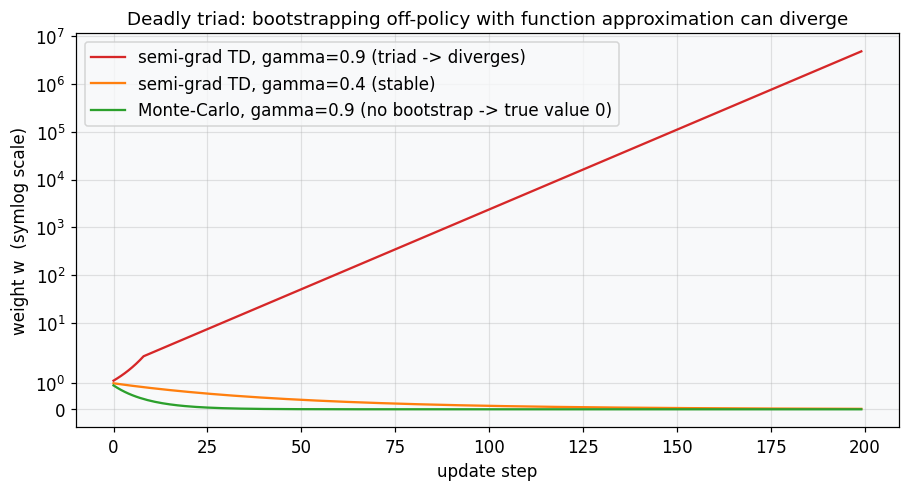

In [9]:
fig, ax = plt.subplots(figsize=(8.4, 4.6))
ax.plot(td_div, color='#d62728', label='semi-grad TD, gamma=0.9 (triad -> diverges)')
ax.plot(td_ok, color='#ff7f0e', label='semi-grad TD, gamma=0.4 (stable)')
ax.plot(mc, color='#2ca02c', label='Monte-Carlo, gamma=0.9 (no bootstrap -> true value 0)')
ax.set_yscale('symlog')
ax.set_xlabel('update step'); ax.set_ylabel('weight w  (symlog scale)')
ax.set_title('Deadly triad: bootstrapping off-policy with function approximation can diverge')
ax.legend()
plt.tight_layout(); plt.show()

### What you see

With $\gamma=0.9$ semi-gradient TD (red) the single weight $w$ grows without bound — the value estimate
diverges even though the true value is exactly 0. Drop $\gamma$ to 0.4 (orange) and the same update is a
contraction, so it stays bounded. Monte-Carlo (green), which uses the true return instead of a bootstrapped
target, converges to 0 regardless of $\gamma$.

**Why.** The bootstrap target $\gamma\,2w$ depends on the *same* weight being updated, and the off-policy
update direction does not correct for the state distribution. Approximation error feeds back into the target,
amplifying itself each step — the deadly triad. Removing any leg (here, bootstrapping) removes the divergence.

**Takeaway.** Value learning is powerful but not free: the convenience of bootstrapping interacts dangerously
with function approximation and off-policy data. This is why practical latent critics use target networks,
distributional (symlog two-hot) heads, clipped double critics, and careful data distributions — and why
Layer A should monitor TD error as an early divergence signal.

## Summary / Key Takeaways

- **Bellman / TD (Exp 1)** — a value head is the fixed point of $v(z)=\mathbb{E}[r+\gamma v(z')]$; sampled
  TD(0) updates converge to the exact solution on a latent MDP.
- **$\lambda$-return (Exp 2)** — $\lambda$ trades critic bias against sampling variance; the estimator MSE is
  U-shaped, so Dreamer's intermediate $\lambda$ beats both pure TD and pure Monte-Carlo.
- **Bootstrap beats long rollouts (Exp 3)** — a terminal value lets short horizons be accurate and
  far-sighted, swapping compounding *dynamics* error for non-compounding *critic* error.
- **Deadly triad (Exp 4)** — bootstrapping + function approximation + off-policy data can diverge even when
  the true value is finite; this motivates target networks, distributional critics, and TD-error monitoring.